In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import gpplot as gpp
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import random
import scipy
from statsmodels.stats.multitest import multipletests


gpp.set_aesthetics(context="paper")

## Vienna dual

Examining screening data reported in [Lukasiak et al 2025](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-025-11386-3)


Downloaded zip file from zenodo, then found day 21 lethality count data for the HCC827 cell line as an example

Goal: Assess the separation of essential/nonessential genes in the dual vienna library (6 guides per gene, 2 guides per construct)

According to sample files,vienna_dual_gw_human is the pDNA, and the rest of the data are the replicates.

In [28]:
dualvienna_counts=pd.read_table("../Data/Lukasiak 2025/vienna_dual_HCC827_day21_counts.txt")


In [29]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['vienna_dual_gw_human','TECHDEV0012_VBCdg_01_01_14', 'TECHDEV0012_VBCdg_01_01_15']
lognorm_df = dualvienna_counts.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove('vienna_dual_gw_human')
lognorm_df

,sgRNA,gene,TECHDEV0012_VBCdg_01_01_15,vienna_dual_gw_human,TECHDEV0012_VBCdg_01_01_14
0,Vienna_A1BG_1-Vienna_A1BG_4,A1BG,4.773615,4.235225,4.498010
1,Vienna_A1BG_2-Vienna_A1BG_5,A1BG,4.552417,4.515690,4.244897
2,Vienna_A1BG_3-Vienna_A1BG_6,A1BG,2.882092,3.542103,3.958323
3,Vienna_A1CF_1-Vienna_A1CF_4,A1CF,2.411460,3.542103,2.520535
4,Vienna_A1CF_2-Vienna_A1CF_5,A1CF,5.047754,4.344039,5.425608
...,...,...,...,...,...
57269,Control-v3-CTRL00896-Control-v3-CTRL00967,Control,6.493497,5.053235,6.285757
57270,Control-v3-CTRL00919-Control-v3-CTRL01001,Control,3.534100,2.890429,3.326991
57271,Control-v3-CTRL00929-Control-v3-CTRL00936,Control,6.287514,4.900485,6.465592
57272,Control-v3-CTRL00935-Control-v3-CTRL00998,Control,5.212299,4.462111,5.418192


In [30]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['vienna_dual_gw_human'] - filtered_lognorms['vienna_dual_gw_human'].mean())/filtered_lognorms['vienna_dual_gw_human'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,sgRNA,gene,TECHDEV0012_VBCdg_01_01_15,vienna_dual_gw_human,TECHDEV0012_VBCdg_01_01_14
0,Vienna_A1BG_1-Vienna_A1BG_4,A1BG,4.773615,4.235225,4.498010
1,Vienna_A1BG_2-Vienna_A1BG_5,A1BG,4.552417,4.515690,4.244897
2,Vienna_A1BG_3-Vienna_A1BG_6,A1BG,2.882092,3.542103,3.958323
3,Vienna_A1CF_1-Vienna_A1CF_4,A1CF,2.411460,3.542103,2.520535
4,Vienna_A1CF_2-Vienna_A1CF_5,A1CF,5.047754,4.344039,5.425608
...,...,...,...,...,...
56326,Control-v3-CTRL00896-Control-v3-CTRL00967,Control,6.493497,5.053235,6.285757
56327,Control-v3-CTRL00919-Control-v3-CTRL01001,Control,3.534100,2.890429,3.326991
56328,Control-v3-CTRL00929-Control-v3-CTRL00936,Control,6.287514,4.900485,6.465592
56329,Control-v3-CTRL00935-Control-v3-CTRL00998,Control,5.212299,4.462111,5.418192


In [31]:
#get log fold change from pDNA
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["vienna_dual_gw_human"]
lfc_df=lfc_df.drop("vienna_dual_gw_human",axis=1)
lfc_df

,sgRNA,gene,TECHDEV0012_VBCdg_01_01_15,TECHDEV0012_VBCdg_01_01_14
0,Vienna_A1BG_1-Vienna_A1BG_4,A1BG,0.538390,0.262785
1,Vienna_A1BG_2-Vienna_A1BG_5,A1BG,0.036727,-0.270793
2,Vienna_A1BG_3-Vienna_A1BG_6,A1BG,-0.660011,0.416220
3,Vienna_A1CF_1-Vienna_A1CF_4,A1CF,-1.130643,-1.021568
4,Vienna_A1CF_2-Vienna_A1CF_5,A1CF,0.703715,1.081569
...,...,...,...,...
56326,Control-v3-CTRL00896-Control-v3-CTRL00967,Control,1.440262,1.232522
56327,Control-v3-CTRL00919-Control-v3-CTRL01001,Control,0.643671,0.436562
56328,Control-v3-CTRL00929-Control-v3-CTRL00936,Control,1.387029,1.565107
56329,Control-v3-CTRL00935-Control-v3-CTRL00998,Control,0.750187,0.956080


In [32]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
lfc_correlations

,TECHDEV0012_VBCdg_01_01_15,TECHDEV0012_VBCdg_01_01_14
TECHDEV0012_VBCdg_01_01_15,1.000000,0.910407
TECHDEV0012_VBCdg_01_01_14,0.910407,1.000000


In [33]:
lfc_df["lfc"]=lfc_df[["TECHDEV0012_VBCdg_01_01_15","TECHDEV0012_VBCdg_01_01_14"]].mean(axis=1)
lfcs_replicates_averaged=lfc_df.drop(["TECHDEV0012_VBCdg_01_01_15","TECHDEV0012_VBCdg_01_01_14"],axis=1)
lfcs_replicates_averaged

,sgRNA,gene,lfc
0,Vienna_A1BG_1-Vienna_A1BG_4,A1BG,0.400587
1,Vienna_A1BG_2-Vienna_A1BG_5,A1BG,-0.117033
2,Vienna_A1BG_3-Vienna_A1BG_6,A1BG,-0.121896
3,Vienna_A1CF_1-Vienna_A1CF_4,A1CF,-1.076106
4,Vienna_A1CF_2-Vienna_A1CF_5,A1CF,0.892642
...,...,...,...
56326,Control-v3-CTRL00896-Control-v3-CTRL00967,Control,1.336392
56327,Control-v3-CTRL00919-Control-v3-CTRL01001,Control,0.540117
56328,Control-v3-CTRL00929-Control-v3-CTRL00936,Control,1.476068
56329,Control-v3-CTRL00935-Control-v3-CTRL00998,Control,0.853134


In [34]:
control_sgrna_lfcs = lfcs_replicates_averaged[(lfcs_replicates_averaged['gene']=="Control")].reset_index(drop=True)
print("# control constructs:", len(control_sgrna_lfcs))
control_mean=control_sgrna_lfcs["lfc"].mean()
control_sd=control_sgrna_lfcs["lfc"].std()

zscored_sgrna_lfcs_dual = lfcs_replicates_averaged.copy()
zscored_sgrna_lfcs_dual['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs_dual['lfc'] - control_mean)/
                                          control_sd)
zscored_sgrna_lfcs_dual = zscored_sgrna_lfcs_dual.drop('lfc', axis=1)
zscored_sgrna_lfcs_dual_all=zscored_sgrna_lfcs_dual.copy()
zscored_sgrna_lfcs_dual

# control constructs: 244


,sgRNA,gene,z_scored_sgRNA_lfc
0,Vienna_A1BG_1-Vienna_A1BG_4,A1BG,-0.868190
1,Vienna_A1BG_2-Vienna_A1BG_5,A1BG,-1.719887
2,Vienna_A1BG_3-Vienna_A1BG_6,A1BG,-1.727889
3,Vienna_A1CF_1-Vienna_A1CF_4,A1CF,-3.297955
4,Vienna_A1CF_2-Vienna_A1CF_5,A1CF,-0.058559
...,...,...,...
56326,Control-v3-CTRL00896-Control-v3-CTRL00967,Control,0.671591
56327,Control-v3-CTRL00919-Control-v3-CTRL01001,Control,-0.638608
56328,Control-v3-CTRL00929-Control-v3-CTRL00936,Control,0.901416
56329,Control-v3-CTRL00935-Control-v3-CTRL00998,Control,-0.123566


In [35]:
noness_genes = pd.read_csv("../../2. Developing promiscuous classifier/Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
noness_genes["Gene"]=noness_genes["Gene"].str.replace(" ","")
noness_gene_list=noness_genes["Gene"].tolist()

essential_genes = pd.read_csv("../../2. Developing promiscuous classifier/Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
essential_genes["Gene"]=essential_genes["Gene"].str.replace(" ","")
essential_gene_list=essential_genes["Gene"].tolist()


Identify the number of nonessential genes that emerge as a depleting hit

In [36]:
grouped_gene_lfcs_dual = (all_guidezscores.groupby('gene')
                     .agg(n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())
genes_with_below_4_constructs_dual=grouped_gene_lfcs_dual[grouped_gene_lfcs_dual["n_sgrnas"]<4]["gene"].tolist()


In [37]:
bottom_5percent_intergenics=zscored_sgrna_lfcs_dual_all[zscored_sgrna_lfcs_dual_all['gene'].str.count("Control")>0]["z_scored_sgRNA_lfc"].quantile(0.05)
zscored_sgrna_lfcs_dual_essential=zscored_sgrna_lfcs_dual_all[zscored_sgrna_lfcs_dual_all["gene"].isin(essential_gene_list)]

#identify the number of guides per essential gene that are more depleted than 95% of negative control guides
essential_zscores_depletedguides=zscored_sgrna_lfcs_dual_essential[(zscored_sgrna_lfcs_dual_essential["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics)]
depletedguidecounts_essentials=essential_zscores_depletedguides.groupby("gene").agg(n_guides=("sgRNA","count")).reset_index()
counts_of_counts=pd.DataFrame(depletedguidecounts_essentials["n_guides"].value_counts()).reset_index()
counts_of_counts=counts_of_counts.sort_values(by="n_guides",ascending=False)
counts_of_counts["n_guides"]=counts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides=len(zscored_sgrna_lfcs_dual_essential[zscored_sgrna_lfcs_dual_essential["gene"].isin(essential_zscores_depletedguides["gene"].tolist())==False]["gene"].unique())
dual_essential_depleted_guidecounts_pergene = pd.concat([counts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides]})], ignore_index=True)
dual_essential_depleted_guidecounts_pergene

,n_guides,count
0,3,1133
1,2,78
2,1,8
3,0,1


In [38]:
zscored_sgrna_lfcs_dual_nonessential=zscored_sgrna_lfcs_dual_all[zscored_sgrna_lfcs_dual_all["gene"].isin(noness_gene_list)]
zscored_sgrna_lfcs_dual_nonessential=zscored_sgrna_lfcs_dual_nonessential[zscored_sgrna_lfcs_dual_nonessential["gene"].isin(genes_with_below_4_constructs)]
#identify the number of guides per nonessential gene that are more depleted than 95% of negative control guides
nonessential_zscores_depletedguides=zscored_sgrna_lfcs_dual_nonessential[(zscored_sgrna_lfcs_dual_nonessential["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics)]
depletedguidecounts_nonessentials=nonessential_zscores_depletedguides.groupby("gene").agg(n_guides=("sgRNA","count")).reset_index()
counts_of_counts=pd.DataFrame(depletedguidecounts_nonessentials["n_guides"].value_counts()).reset_index()
counts_of_counts=counts_of_counts.sort_values(by="n_guides",ascending=False)
counts_of_counts["n_guides"]=counts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides=len(zscored_sgrna_lfcs_dual_nonessential[zscored_sgrna_lfcs_dual_nonessential["gene"].isin(nonessential_zscores_depletedguides["gene"].tolist())==False]["gene"].unique())
dual_nonessential_depleted_guidecounts_pergene = pd.concat([counts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides]})], ignore_index=True)
dual_nonessential_depleted_guidecounts_pergene


,n_guides,count
0,3,58
1,2,173
2,1,302
3,0,209


## Vienna single


Downloaded zip file from Lukasiak et al 2025 zenodo, then found day 23 lethality count data for the HCC827 cell line 

According to sample files,vienna_v1_single_top3 is the pDNA, and the rest of the data are the replicates.

In [39]:
counts=pd.read_table("../Data/Lukasiak 2025/vienna_single_HCC827_day23_counts.txt")
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['vienna_v1_single_top3','TECHDEV0012_Vienna_01_01_17', 'TECHDEV0012_Vienna_01_01_16']
lognorm_df = counts.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove('vienna_v1_single_top3')
lognorm_df

,sgRNA,gene,vienna_v1_single_top3,TECHDEV0012_Vienna_01_01_17,TECHDEV0012_Vienna_01_01_16
0,Vienna-A1BG-1,A1BG,4.774046,5.050541,5.439794
1,Vienna-A1BG-2,A1BG,3.321379,4.426338,3.894789
2,Vienna-A1BG-3,A1BG,4.467971,4.556348,4.329998
3,Vienna-A1CF-1,A1CF,3.738078,4.438880,4.042881
4,Vienna-A1CF-2,A1CF,4.114257,3.874541,4.413235
...,...,...,...,...,...
57516,Control_v3_CTRL00496,Control,4.061002,4.161606,3.663283
57517,Control_v3_CTRL00497,Control,4.182338,4.436381,4.428706
57518,Control_v3_CTRL00498,Control,3.464964,4.173663,3.626189
57519,Control_v3_CTRL00499,Control,4.585775,5.214163,5.707969


In [40]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['vienna_v1_single_top3'] - filtered_lognorms['vienna_v1_single_top3'].mean())/filtered_lognorms['vienna_v1_single_top3'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,sgRNA,gene,vienna_v1_single_top3,TECHDEV0012_Vienna_01_01_17,TECHDEV0012_Vienna_01_01_16
0,Vienna-A1BG-1,A1BG,4.774046,5.050541,5.439794
1,Vienna-A1BG-2,A1BG,3.321379,4.426338,3.894789
2,Vienna-A1BG-3,A1BG,4.467971,4.556348,4.329998
3,Vienna-A1CF-1,A1CF,3.738078,4.438880,4.042881
4,Vienna-A1CF-2,A1CF,4.114257,3.874541,4.413235
...,...,...,...,...,...
56862,Control_v3_CTRL00496,Control,4.061002,4.161606,3.663283
56863,Control_v3_CTRL00497,Control,4.182338,4.436381,4.428706
56864,Control_v3_CTRL00498,Control,3.464964,4.173663,3.626189
56865,Control_v3_CTRL00499,Control,4.585775,5.214163,5.707969


In [41]:
#get log fold change from pDNA
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["vienna_v1_single_top3"]
lfc_df=lfc_df.drop("vienna_v1_single_top3",axis=1)
lfc_df

,sgRNA,gene,TECHDEV0012_Vienna_01_01_17,TECHDEV0012_Vienna_01_01_16
0,Vienna-A1BG-1,A1BG,0.276495,0.665748
1,Vienna-A1BG-2,A1BG,1.104959,0.573410
2,Vienna-A1BG-3,A1BG,0.088377,-0.137973
3,Vienna-A1CF-1,A1CF,0.700802,0.304803
4,Vienna-A1CF-2,A1CF,-0.239716,0.298978
...,...,...,...,...
56862,Control_v3_CTRL00496,Control,0.100604,-0.397719
56863,Control_v3_CTRL00497,Control,0.254043,0.246368
56864,Control_v3_CTRL00498,Control,0.708699,0.161225
56865,Control_v3_CTRL00499,Control,0.628387,1.122194


In [42]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
lfc_correlations

,TECHDEV0012_Vienna_01_01_17,TECHDEV0012_Vienna_01_01_16
TECHDEV0012_Vienna_01_01_17,1.000000,0.914445
TECHDEV0012_Vienna_01_01_16,0.914445,1.000000


In [43]:
lfc_df["lfc"]=lfc_df[["TECHDEV0012_Vienna_01_01_17","TECHDEV0012_Vienna_01_01_16"]].mean(axis=1)
lfcs_replicates_averaged=lfc_df.drop(["TECHDEV0012_Vienna_01_01_17","TECHDEV0012_Vienna_01_01_16"],axis=1)
lfcs_replicates_averaged

,sgRNA,gene,lfc
0,Vienna-A1BG-1,A1BG,0.471122
1,Vienna-A1BG-2,A1BG,0.839185
2,Vienna-A1BG-3,A1BG,-0.024798
3,Vienna-A1CF-1,A1CF,0.502803
4,Vienna-A1CF-2,A1CF,0.029631
...,...,...,...
56862,Control_v3_CTRL00496,Control,-0.148558
56863,Control_v3_CTRL00497,Control,0.250205
56864,Control_v3_CTRL00498,Control,0.434962
56865,Control_v3_CTRL00499,Control,0.875291


In [44]:
control_sgrna_lfcs = lfcs_replicates_averaged[(lfcs_replicates_averaged['gene']=="Control")].reset_index(drop=True)
print("# control constructs:", len(control_sgrna_lfcs))
control_mean=control_sgrna_lfcs["lfc"].mean()
control_sd=control_sgrna_lfcs["lfc"].std()

zscored_sgrna_lfcs_single = lfcs_replicates_averaged.copy()
zscored_sgrna_lfcs_single['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs_single['lfc'] - control_mean)/
                                          control_sd)
zscored_sgrna_lfcs_single = zscored_sgrna_lfcs_single.drop('lfc', axis=1)
zscored_sgrna_lfcs_single

# control constructs: 485


,sgRNA,gene,z_scored_sgRNA_lfc
0,Vienna-A1BG-1,A1BG,-0.268593
1,Vienna-A1BG-2,A1BG,0.247131
2,Vienna-A1BG-3,A1BG,-0.963467
3,Vienna-A1CF-1,A1CF,-0.224202
4,Vienna-A1CF-2,A1CF,-0.887203
...,...,...,...
56862,Control_v3_CTRL00496,Control,-1.136878
56863,Control_v3_CTRL00497,Control,-0.578137
56864,Control_v3_CTRL00498,Control,-0.319260
56865,Control_v3_CTRL00499,Control,0.297723


In [47]:
bottom_5percent_intergenics=zscored_sgrna_lfcs_single[zscored_sgrna_lfcs_single['gene'].str.count("Control")>0]["z_scored_sgRNA_lfc"].quantile(0.05)
zscored_sgrna_lfcs_essential=zscored_sgrna_lfcs_single[zscored_sgrna_lfcs_single["gene"].isin(essential_gene_list)]

#identify the number of guides per essential gene that are more depleted than 95% of negative control guides
essential_zscores_depletedguides=zscored_sgrna_lfcs_essential[(zscored_sgrna_lfcs_essential["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics)]
depletedguidecounts_essentials=essential_zscores_depletedguides.groupby("gene").agg(n_guides=("sgRNA","count")).reset_index()
counts_of_counts=pd.DataFrame(depletedguidecounts_essentials["n_guides"].value_counts()).reset_index()
counts_of_counts=counts_of_counts.sort_values(by="n_guides",ascending=False)
counts_of_counts["n_guides"]=counts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides=len(zscored_sgrna_lfcs_essential[zscored_sgrna_lfcs_essential["gene"].isin(essential_zscores_depletedguides["gene"].tolist())==False]["gene"].unique())
single_essential_depleted_guidecounts_pergene = pd.concat([counts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides]})], ignore_index=True)
single_essential_depleted_guidecounts_pergene

,n_guides,count
0,3,1056
1,2,133
2,1,29
3,0,2


In [48]:
zscored_sgrna_lfcs_nonessential=zscored_sgrna_lfcs_single[zscored_sgrna_lfcs_single["gene"].isin(noness_gene_list)]

#identify the number of guides per nonessential gene that are more depleted than 95% of negative control guides
nonessential_zscores_depletedguides=zscored_sgrna_lfcs_nonessential[(zscored_sgrna_lfcs_nonessential["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics)]
depletedguidecounts_nonessentials=nonessential_zscores_depletedguides.groupby("gene").agg(n_guides=("sgRNA","count")).reset_index()
counts_of_counts=pd.DataFrame(depletedguidecounts_nonessentials["n_guides"].value_counts()).reset_index()
counts_of_counts=counts_of_counts.sort_values(by="n_guides",ascending=False)
counts_of_counts["n_guides"]=counts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides=len(zscored_sgrna_lfcs_nonessential[zscored_sgrna_lfcs_nonessential["gene"].isin(nonessential_zscores_depletedguides["gene"].tolist())==False]["gene"].unique())
single_nonessential_depleted_guidecounts_pergene = pd.concat([counts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides]})], ignore_index=True)
single_nonessential_depleted_guidecounts_pergene


,n_guides,count
0,3,21
1,2,115
2,1,280
3,0,340


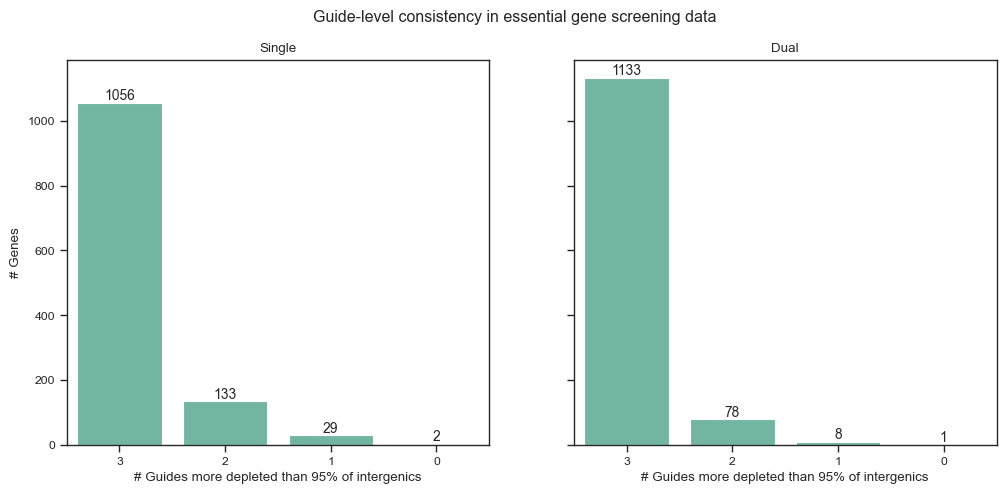

In [53]:
(fig,ax)=plt.subplots(1,2,figsize=(12,5),sharey=True)

fig.suptitle("Guide-level consistency in essential gene screening data ")

sns.barplot(single_essential_depleted_guidecounts_pergene,x="n_guides",y="count",ax=ax[0])
ax[0].set_xlabel("# Guides more depleted than 95% of intergenics")
ax[0].set_ylabel("# Genes")
ax[0].set_title("Single")
ax[0].bar_label(ax[0].containers[0], fontsize=10);


sns.barplot(dual_essential_depleted_guidecounts_pergene,x="n_guides",y="count",ax=ax[1])
ax[1].set_xlabel("# Guides more depleted than 95% of intergenics")
ax[1].set_ylabel("# Genes")
ax[1].set_title("Dual")
ax[1].bar_label(ax[1].containers[0], fontsize=10);

gpp.savefig("../Figures/guidelevelconsistency_vienna_dual_vs_single_essential.pdf")

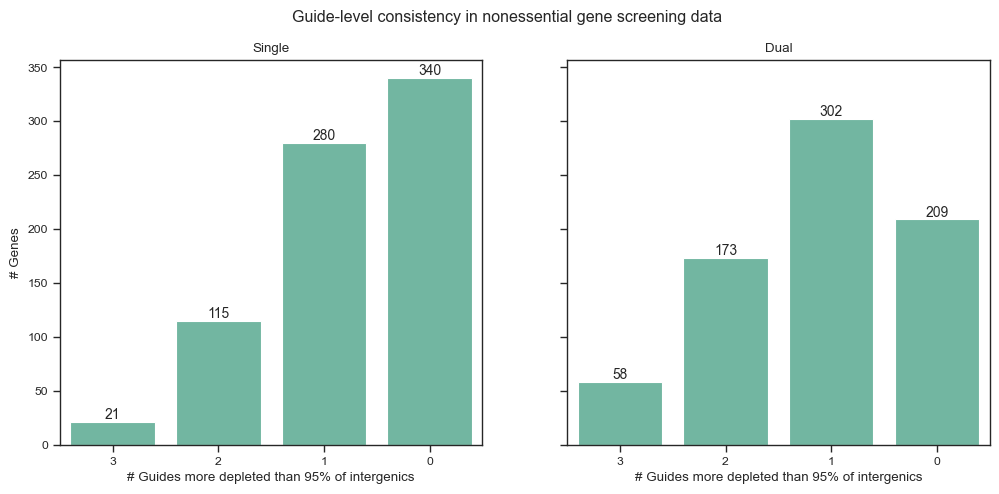

In [58]:
(fig,ax)=plt.subplots(1,2,figsize=(12,5),sharey=True)

fig.suptitle("Guide-level consistency in nonessential gene screening data ")

sns.barplot(single_nonessential_depleted_guidecounts_pergene,x="n_guides",y="count",ax=ax[0])
ax[0].set_xlabel("# Guides more depleted than 95% of intergenics")
ax[0].set_ylabel("# Genes")
ax[0].set_title("Single")
ax[0].bar_label(ax[0].containers[0], fontsize=10);


sns.barplot(dual_nonessential_depleted_guidecounts_pergene,x="n_guides",y="count",ax=ax[1])
ax[1].set_xlabel("# Guides more depleted than 95% of intergenics")
ax[1].set_ylabel("# Genes")
ax[1].set_title("Dual")
ax[1].bar_label(ax[1].containers[0], fontsize=10);

gpp.savefig("../Figures/guidelevelconsistency_vienna_dual_vs_single_nonessential.pdf")

In [60]:
print("SINGLE fraction of nonessential genes with 2 out of 3 guides depleted:",(21+115)/(21+115+280+240))
print("DUAL fraction of nonessential genes with 2 out of 3 guides depleted:",(58+173)/(58+173+302+209))


SINGLE fraction of nonessential genes with 2 out of 3 guides depleted: 0.2073170731707317
DUAL fraction of nonessential genes with 2 out of 3 guides depleted: 0.3113207547169811


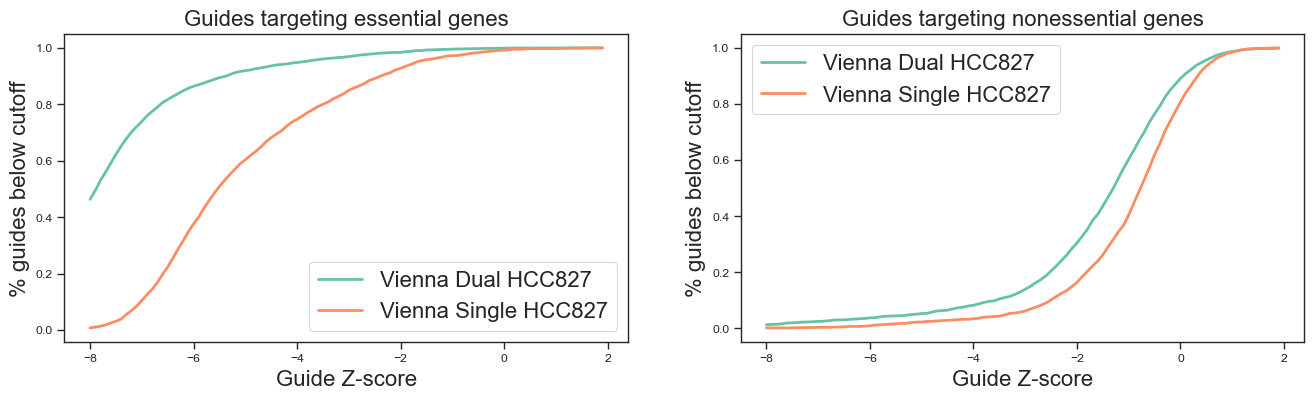

In [57]:
zscored_guide_lfcs_essentials_dual=zscored_sgrna_lfcs_dual[zscored_sgrna_lfcs_dual["gene"].isin(essential_gene_list)].reset_index(drop=True)
zscored_guide_lfcs_essentials_single=zscored_sgrna_lfcs_single[zscored_sgrna_lfcs_single["gene"].isin(essential_gene_list)].reset_index(drop=True)

guide_z_cutoffs= [x*0.1 for x in range(-80,20)]

percent_guides_below_cutoff_viennadual=[]
percent_guides_below_cutoff_viennasingle=[]


for cutoff in guide_z_cutoffs:
    percent_guides_below_cutoff_viennadual.append(len(zscored_guide_lfcs_essentials_dual[zscored_guide_lfcs_essentials_dual["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_essentials_dual))
    percent_guides_below_cutoff_viennasingle.append(len(zscored_guide_lfcs_essentials_single[zscored_guide_lfcs_essentials_single["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_essentials_single))


fig, ax = plt.subplots(1,2,figsize=(16,4))
ax[0].plot(guide_z_cutoffs,percent_guides_below_cutoff_viennadual,label="Vienna Dual HCC827",linewidth=2)
ax[0].plot(guide_z_cutoffs,percent_guides_below_cutoff_viennasingle,label="Vienna Single HCC827",linewidth=2)

ax[0].set_xlabel("Guide Z-score",fontsize=16)
ax[0].set_ylabel("% guides below cutoff",fontsize=16)
ax[0].set_title("Guides targeting essential genes",fontsize=16)
ax[0].legend(fontsize=16)

#repeat for nonessentials
zscored_guide_lfcs_nonessentials_dual=zscored_sgrna_lfcs_dual[zscored_sgrna_lfcs_dual["gene"].isin(noness_gene_list)].reset_index(drop=True)
zscored_guide_lfcs_nonessentials_single=zscored_sgrna_lfcs_single[zscored_sgrna_lfcs_single["gene"].isin(noness_gene_list)].reset_index(drop=True)


percent_guides_below_cutoff_viennadual=[]
percent_guides_below_cutoff_viennasingle=[]

for cutoff in guide_z_cutoffs:
    percent_guides_below_cutoff_viennadual.append(len(zscored_guide_lfcs_nonessentials_dual[zscored_guide_lfcs_nonessentials_dual["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_nonessentials_dual))
    percent_guides_below_cutoff_viennasingle.append(len(zscored_guide_lfcs_nonessentials_single[zscored_guide_lfcs_nonessentials_single["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_nonessentials_single))

ax[1].plot(guide_z_cutoffs,percent_guides_below_cutoff_viennadual,label="Vienna Dual HCC827",linewidth=2)
ax[1].plot(guide_z_cutoffs,percent_guides_below_cutoff_viennasingle,label="Vienna Single HCC827",linewidth=2)

ax[1].set_xlabel("Guide Z-score",fontsize=16)
ax[1].set_ylabel("% guides below cutoff",fontsize=16)
ax[1].set_title("Guides targeting nonessential genes",fontsize=16)
ax[1].legend(fontsize=16)

                       
gpp.savefig("../Figures/Vienna_single_vs_dual_essentials_nonessentials_cumulativedist.pdf")